In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load and do basic fix
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')
df.rename(columns={'ï»¿Type': 'Type'}, inplace=True)

# Drop unusable columns
df = df.drop(columns=['Product Description', 'Order Zipcode'])

# Fill small missing values
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')
df['Customer Zipcode'] = df['Customer Zipcode'].fillna('Unknown')

# Fix date column
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

# Cap outliers in Benefit per order
lower_cap = df['Benefit per order'].quantile(0.01)
upper_cap = df['Benefit per order'].quantile(0.99)
df['Benefit per order'] = df['Benefit per order'].clip(lower=lower_cap, upper=upper_cap)

# Normalize selected columns
cols_to_normalize = ['Sales per customer', 'Benefit per order', 'Days for shipping (real)']
scaler = MinMaxScaler()
df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,0.500000,4,0.844989,0.158939,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,0.833333,4,0.277595,0.157242,Late delivery,1,73,Sporting Goods,Caguas,...,RajastÃ¡n,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,0.666667,4,0.279779,0.156393,Shipping on time,0,73,Sporting Goods,San Jose,...,RajastÃ¡n,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,0.500000,4,0.730974,0.153853,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,0.333333,4,0.916610,0.150458,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [3]:
# contral tendency and spread
df[['Days for shipping (real)', 'Order Item Total', 'Benefit per order']].describe()

,Days for shipping (real),Order Item Total,Benefit per order
count,180519.000000,180519.000000,180519.000000
mean,0.582942,183.107609,0.731775
std,0.270620,120.043670,0.146206
min,0.000000,7.490000,0.000000
25%,0.333333,104.379997,0.704533
50%,0.500000,163.990005,0.745411
75%,0.833333,247.399994,0.800893
max,1.000000,1939.989990,1.000000


In [4]:
# correlation between variables
df[['Days for shipping (real)', 'Days for shipment (scheduled)', 'Order Item Total', 'Benefit per order', 'Late_delivery_risk']].corr()

,Days for shipping (real),Days for shipment (scheduled),Order Item Total,Benefit per order,Late_delivery_risk
Days for shipping (real),1.000000,0.515880,0.001757,-0.004719,0.401415
Days for shipment (scheduled),0.515880,1.000000,0.006445,-0.000546,-0.369352
Order Item Total,0.001757,0.006445,1.000000,0.163679,-0.003791
Benefit per order,-0.004719,-0.000546,0.163679,1.000000,-0.003355
Late_delivery_risk,0.401415,-0.369352,-0.003791,-0.003355,1.000000


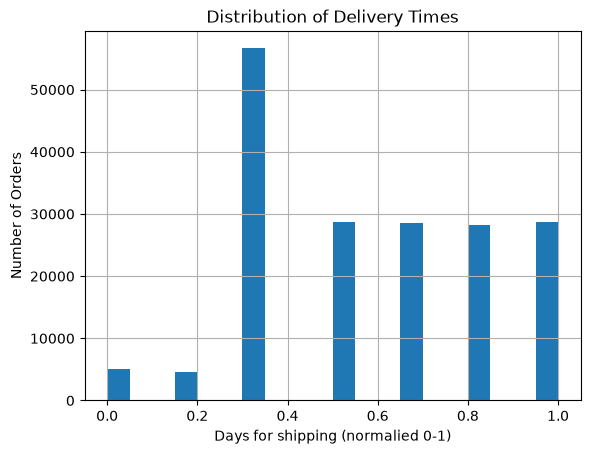

In [5]:
import matplotlib.pyplot as plt

df['Days for shipping (real)'].hist(bins=20)
plt.title('Distribution of Delivery Times')
plt.xlabel('Days for shipping (normalied 0-1)')
plt.ylabel('Number of Orders')
plt.show()

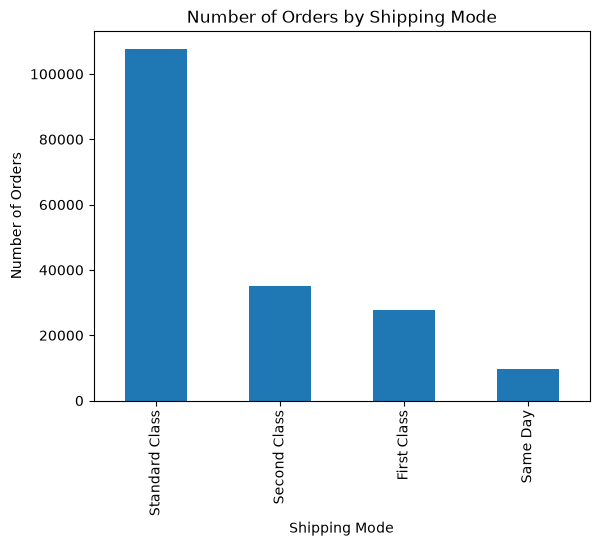

In [7]:
df['Shipping Mode'].value_counts().plot(kind='bar')
plt.title('Number of Orders by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')
plt.show()

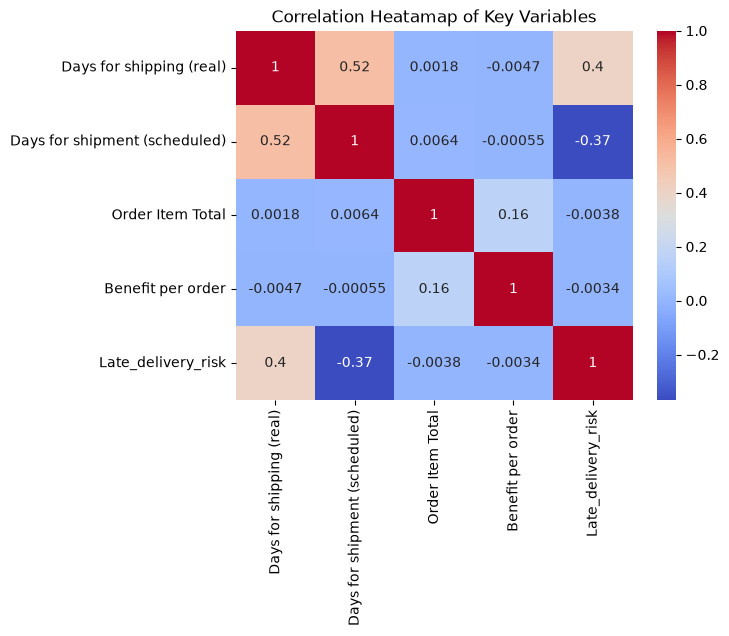

In [9]:
import seaborn as sns

corr_data = df[['Days for shipping (real)','Days for shipment (scheduled)','Order Item Total','Benefit per order','Late_delivery_risk']].corr()

sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title('Correlation Heatamap of Key Variables')
plt.show()